In [1]:
# 1. Clean out the broken and conflicting installations completely
!pip uninstall scispacy en-core-sci-sm spacy thinc numpy -y -q

# 2. Install the exact matching versions for the 0.5.x scispacy architecture
!pip install spacy==3.7.5 numpy==1.26.4 -q

# 3. Install scispacy version 0.5.5 (which works seamlessly with SpaCy 3.7.x)
!pip install scispacy==0.5.5 -q
!pip install nmslib exactextract -q

# 4. Install the corresponding matching version of the clinical model
!pip install https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_core_sci_sm-0.5.4.tar.gz -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 w

Please upload your mtsamples.csv file...


Saving mtsamples.csv to mtsamples.csv
Dataset shape: (4999, 6)
Column list: ['Unnamed: 0', 'description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']

Specialities:
medical_specialty
Surgery                          1103
Consult - History and Phy.        516
Cardiovascular / Pulmonary        372
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  230
Neurology                         223
SOAP / Chart / Progress Notes     166
Obstetrics / Gynecology           160
Urology                           158
Discharge Summary                 108
ENT - Otolaryngology               98
Neurosurgery                       94
Hematology - Oncology              90
Ophthalmology                      83
Nephrology                         81
Emergency Room Reports             75
Pediatrics - Neonatal              70
Pain Management                    62
Psychiatry / Psychology            5

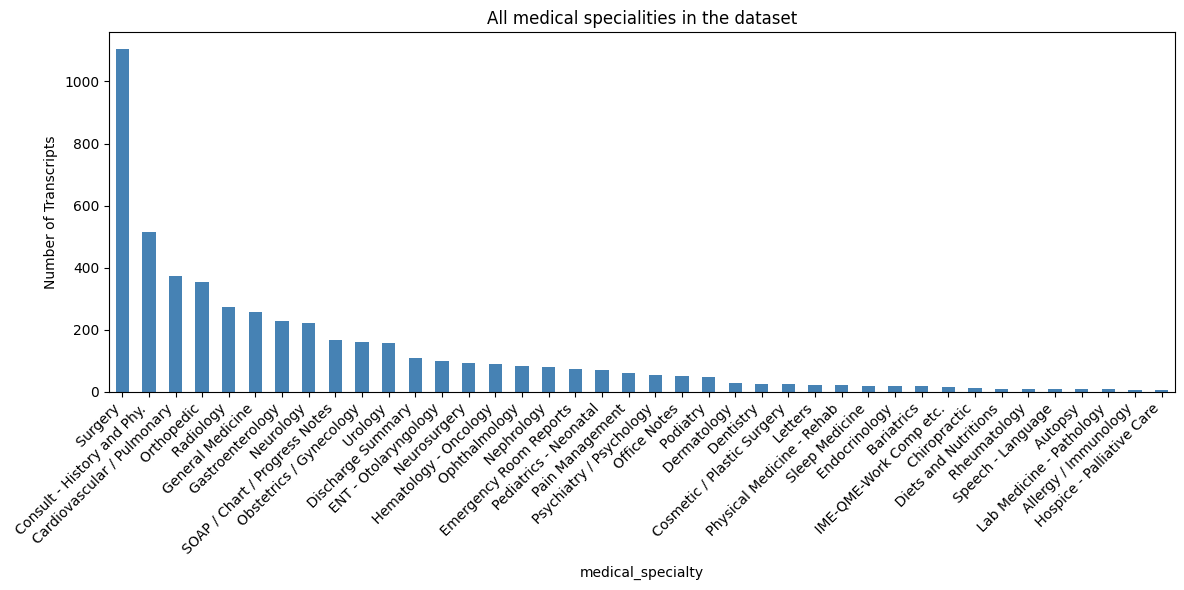

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# ── Load dataset on Google Colab ──────────────────────────────────────────────
from google.colab import files
print("Please upload your mtsamples.csv file...")
uploaded = files.upload()  # A file picker will pop up — select mtsamples.csv

df = pd.read_csv('mtsamples.csv')

print(f'Dataset shape: {df.shape}')
print(f'Column list: {df.columns.tolist()}')

df['transcription'] = df['transcription'].fillna('')

specialities = df['medical_specialty'].value_counts()
print(f'\nSpecialities:\n{specialities}')

plt.figure(figsize=(12, 6))
specialities.plot(kind='bar', color='steelblue')
plt.title("All medical specialities in the dataset")
plt.ylabel("Number of Transcripts")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

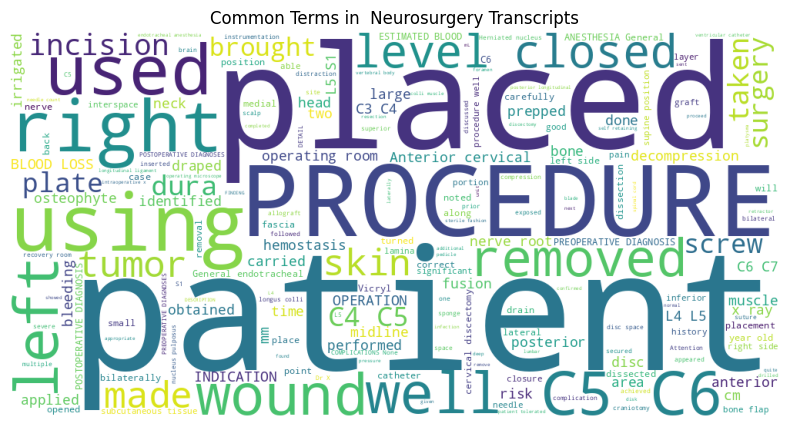

In [3]:
try:
    speciality = ' Neurosurgery'
    if speciality in df['medical_specialty'].values:
        texts = df[df['medical_specialty']==speciality]['transcription']
        if not texts.empty:
            text = ' '.join(texts.astype(str))
            if len(text.strip()) > 0:
                wordcloud = WordCloud(width=1000, height=500, background_color='white').generate(text)
                plt.figure(figsize=(10,5))
                plt.imshow(wordcloud)
                plt.axis("off")
                plt.title(f"Common Terms in {speciality} Transcripts")
                plt.show()

            else:
                print(f"No valid text found for {speciality}")
        else:
            print(f"No transcriptions available for {speciality}")
    else:
        print("Speciality not found in dataset")

except Exception as e:
    print("Error:", str(e))

In [4]:
import re
import nltk
from tqdm import tqdm
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# ── Fix 1: Download punkt_tab (required in newer NLTK versions) ───────────────
nltk.download(['stopwords', 'punkt', 'punkt_tab'], quiet=True)

def clean_text(text):
    if not isinstance(text, str):
        return ""                        # Fix 2: always return a string

    medical_terms = {
        'dr', 'pt', 'mr', 'mri', 'ct', 'hr', 'bp', 'rr', 'spo2',
        'ekg', 'cbc', 'er', 'or', 'ed', 'icu', 'lab'
    }
    try:
        text = text.lower()
        text = re.sub(r'\[.*?\]', '', text)
        text = re.sub(r'\b\d+[\.\d]*\b', '', text)
        text = re.sub(r'[^\w\s]', ' ', text)

        words = word_tokenize(text)
        stop_words = set(stopwords.words('english')) - medical_terms
        filtered_words = [w for w in words if w not in stop_words and len(w) > 1]

        return ' '.join(filtered_words)

    except Exception as e:
        print(f'Error while processing text: {e}')
        return ""                        # Fix 3: return "" instead of None on error

tqdm.pandas(desc="Cleaning Text")
df['clean_text'] = df['transcription'].progress_apply(clean_text)

empty_text = df['clean_text'].str.strip().eq('').sum()

print(f"\nDiagnostics:")
print(f" Original samples : {len(df)}")
print(f" Empty results    : {empty_text} ({empty_text/len(df):.1%})")
print("\nSample Before:\n", df['transcription'].iloc[0][:200])
print("\nSample After:\n",  df['clean_text'].iloc[0][:200])

Cleaning Text: 100%|██████████| 4999/4999 [00:09<00:00, 543.21it/s]


Diagnostics:
 Original samples : 4999
 Empty results    : 33 (0.7%)

Sample Before:
 SUBJECTIVE:,  This 23-year-old white female presents with complaint of allergies.  She used to have allergies when she lived in Seattle but she thinks they are worse here.  In the past, she has tried 

Sample After:
 subjective year old white female presents complaint allergies used allergies lived seattle thinks worse past tried claritin zyrtec worked short time seemed lose effectiveness used allegra also used la


In [5]:
import numpy as np
from sklearn.model_selection import train_test_split

# Fill any remaining NaNs in description and keywords to safely concatenate
df['description'] = df['description'].fillna('')
df['keywords'] = df['keywords'].fillna('')

# ── CONFERENCE BEST PRACTICE ──
# Concatenate fields with explicit structural boundaries so the Transformer
# learns the semantic context of each segment distinctively.
df['combined_text'] = (
    "Description: " + df['description'] + " " +
    "Transcript: " + df['clean_text'] + " " +
    "Keywords: " + df['keywords']
)

# Select target classes to handle class sparsity effectively
target_specialties = [' Surgery', ' Consult - History and Phy.', ' Cardiovascular / Pulmonary', ' Orthopedic', ' Neurology']
df_filtered = df[df['medical_specialty'].isin(target_specialties)].copy()

# Drop rows that yielded empty combined text
df_filtered = df_filtered[df_filtered['combined_text'].str.strip() != ""]

X = df_filtered['combined_text'].values
y = df_filtered['medical_specialty'].values

# Split data FIRST before any oversampling or global vectorization to prevent data leakage
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print(f"Data Split Finalized:")
print(f"-> Training Set Size : {X_train_raw.shape[0]}")
print(f"-> Testing Set Size  : {X_test_raw.shape[0]}")

Data Split Finalized:
-> Training Set Size : 2055
-> Testing Set Size  : 514


In [6]:
import spacy
import scispacy
from scispacy.linking import EntityLinker
from sklearn.feature_extraction.text import TfidfVectorizer

# Load the clinical NER model
nlp = spacy.load("en_core_sci_sm")

# ── CONFERENCE GRADE UPGRADE: Add the UMLS Knowledge Base Linker ──
# Resolves text entities to formal ontologies containing SNOMED-CT concepts
nlp.add_pipe("scispacy_linker", config={"resolve_abbreviations": True, "linker_name": "umls"})
linker = nlp.get_pipe("scispacy_linker")

def extract_ner_and_snomed_features(texts):
    combined_features_docs = []

    # Process text sequentially in efficient batches
    for doc in nlp.pipe(texts, batch_size=32):
        entities_list = []
        concepts_list = []

        for ent in doc.ents:
            # 1. Capture the NER surface text representation
            entities_list.append(ent.text.replace(" ", "_"))

            # 2. Extract SNOMED-CT/UMLS concept mappings
            if ent._.kb_ents:
                # Fetch the top candidate concept ID (CUI) from the knowledge base
                best_concept_match = ent._.kb_ents[0]
                concept_id = best_concept_match[0] # e.g., "C0027051"
                concepts_list.append(concept_id)

        # Fuse linguistic words and structured ontology codes together into a document profile
        unified_doc_string = " ".join(entities_list) + " " + " ".join(concepts_list)
        combined_features_docs.append(unified_doc_string)

    return combined_features_docs

print("Executing NER + Ontological Mapping on Training Data...")
X_train_medical_docs = extract_ner_and_snomed_features(X_train_raw)

print("Executing NER + Ontological Mapping on Testing Data...")
X_test_medical_docs = extract_ner_and_snomed_features(X_test_raw)

# Vectorize the combined entity & mapping space
tfidf_medical = TfidfVectorizer(max_features=2500) # Increased capacity to store texts + concept codes
X_train_ner = tfidf_medical.fit_transform(X_train_medical_docs).toarray()
X_test_ner = tfidf_medical.transform(X_test_medical_docs).toarray()

print(f"Medical Feature Extraction Complete. Matrix Shape: {X_train_ner.shape}")

/usr/local/lib/python3.12/dist-packages/spacy/language.py:2195: FutureWarning: Possible set union at position 6328
  deserializers["tokenizer"] = lambda p: self.tokenizer.from_disk(  # type: ignore[union-attr]


https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/data/linkers/2023-04-23/umls/tfidf_vectors_sparse.npz not found in cache, downloading to /tmp/tmpxh31s67h


100%|██████████| 492M/492M [00:12<00:00, 41.3MiB/s]


Finished download, copying /tmp/tmpxh31s67h to cache at /root/.scispacy/datasets/2b79923846fb52e62d686f2db846392575c8eb5b732d9d26cd3ca9378c622d40.87bd52d0f0ee055c1e455ef54ba45149d188552f07991b765da256a1b512ca0b.tfidf_vectors_sparse.npz
https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/data/linkers/2023-04-23/umls/nmslib_index.bin not found in cache, downloading to /tmp/tmp32sd7xxw


100%|██████████| 724M/724M [00:22<00:00, 34.0MiB/s]


...

Finished download, copying /tmp/tmpxiq1yy30 to cache at /root/.scispacy/datasets/6238f505f56aca33290aab44097f67dd1b88880e3be6d6dcce65e56e9255b7d4.d7f77b1629001b40f1b1bc951f3a890ff2d516fb8fbae3111b236b31b33d6dcf.concept_aliases.json
https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/data/kbs/2023-04-23/umls_2022_ab_cat0129.jsonl not found in cache, downloading to /tmp/tmpz2sdpwmo


100%|██████████| 628M/628M [00:15<00:00, 43.2MiB/s]


Finished download, copying /tmp/tmpz2sdpwmo to cache at /root/.scispacy/datasets/d5e593bc2d8adeee7754be423cd64f5d331ebf26272074a2575616be55697632.0660f30a60ad00fffd8bbf084a18eb3f462fd192ac5563bf50940fc32a850a3c.umls_2022_ab_cat0129.jsonl
https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/data/umls_semantic_type_tree.tsv not found in cache, downloading to /tmp/tmpc9b7fm5t


100%|██████████| 4.26k/4.26k [00:00<00:00, 7.61MiB/s]


Finished download, copying /tmp/tmpc9b7fm5t to cache at /root/.scispacy/datasets/21a1012c532c3a431d60895c509f5b4d45b0f8966c4178b892190a302b21836f.330707f4efe774134872b9f77f0e3208c1d30f50800b3b39a6b8ec21d9adf1b7.umls_semantic_type_tree.tsv
Executing NER + Ontological Mapping on Training Data...
Executing NER + Ontological Mapping on Testing Data...
Medical Feature Extraction Complete. Matrix Shape: (2055, 2500)


In [7]:
!pip install transformers torch -q
from tqdm import tqdm
import torch
from transformers import LongformerTokenizer, LongformerModel

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
tokenizer = LongformerTokenizer.from_pretrained('allenai/longformer-base-4096')
model = LongformerModel.from_pretrained('allenai/longformer-base-4096').to(device)
model.eval()

def get_longformer_embeddings(texts, batch_size=8):
    embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Encoding text sequence"):
        batch_texts = list(texts[i:i+batch_size])

        # Max token length set to 2048 to safely process combined text without memory crashing
        inputs = tokenizer(batch_texts, padding=True, truncation=True, max_length=2048, return_tensors="pt").to(device)

        # Set global attention explicitly on the [CLS] token as required by Longformer architecture
        global_attention_mask = torch.zeros_like(inputs['input_ids'])
        global_attention_mask[:, 0] = 1

        with torch.no_grad():
            outputs = model(
                input_ids=inputs['input_ids'],
                attention_mask=inputs['attention_mask'],
                global_attention_mask=global_attention_mask
            )
            # Pull uncorrupted last hidden state context
            cls_repr = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.append(cls_repr)

    return np.vstack(embeddings)

print("Extracting Longformer Embeddings (Train)...")
X_train_lf = get_longformer_embeddings(X_train_raw)
print("Extracting Longformer Embeddings (Test)...")
X_test_lf = get_longformer_embeddings(X_test_raw)

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/597M [00:00<?, ?B/s]

...

[transformers] LongformerModel LOAD REPORT from: allenai/longformer-base-4096
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Extracting Longformer Embeddings (Train)...



Encoding text sequence:   0%|          | 0/257 [00:00<?, ?it/s][transformers] Input ids are automatically padded to be a multiple of `config.attention_window`: 512

Encoding text sequence: 100%|██████████| 257/257 [04:25<00:00,  1.03s/it]


Extracting Longformer Embeddings (Test)...


Encoding text sequence: 100%|██████████| 65/65 [01:08<00:00,  1.06s/it]


In [ ]:
!pip install imbalanced-learn threadpoolctl -q
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from threadpoolctl import threadpool_limits

# 1. Feature Fusion
X_train_fused = np.hstack((X_train_ner, X_train_lf))
X_test_fused = np.hstack((X_test_ner, X_test_lf))

# Encode target text categories into numerical labels
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train) 
y_test_encoded = le.transform(y_test)

# 2. Build the Stacking Architecture (Strict Single-Threading)
base_learners = [
    ('rf', RandomForestClassifier(n_estimators=150, random_state=42)),
    ('lr', LogisticRegression(max_iter=1500, random_state=42))
]
meta_learner = LogisticRegression()

stacking_classifier = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=3
)

# 3. Encapsulate operations into an imbalance-aware pipeline
pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('classifier', stacking_classifier)
])

print("\nTraining the Fused Knowledge Architecture (Thread-Safe Mode)...")

# ── ULTIMATE SYNTAX FIX FOR YOUR THREADPOOLCTL VERSION ──
# Setting user_api=None applies limits=1 globally across openmp, blas, and scipy seamlessly
with threadpool_limits(limits=1, user_api=None):
    pipeline.fit(X_train_fused, y_train_encoded)

# 4. Generate Final Experimental Predictions
y_pred = pipeline.predict(X_test_fused)

print("\n" + "="*20 + " FINAL REFERRED EVALUATION METRICS " + "="*20)
print(f"Overall Accuracy Score: {accuracy_score(y_test_encoded, y_pred):.4f}")
print("\nDownstream Classification Performance:")
print(classification_report(y_test_encoded, y_pred, target_names=le.classes_))

Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7d890795ce00>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ctypes/__init__.py", line 379, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: dlopen() error
Exception ignored on calling ctypes callback function: <functio


Training the Fused Knowledge Architecture (Thread-Safe Mode)...

==================== FINAL REFERRED EVALUATION METRICS ====================
Overall Accuracy Score: 0.8152

Downstream Classification Performance:
                             precision    recall  f1-score   support

 Cardiovascular / Pulmonary       0.76      0.73      0.74        74
 Consult - History and Phy.       0.76      0.72      0.74       103
                  Neurology       0.62      0.71      0.66        45
                 Orthopedic       0.79      0.79      0.79        71
                    Surgery       0.91      0.92      0.91       221

                   accuracy                           0.82       514
                  macro avg       0.77      0.77      0.77       514
               weighted avg       0.82      0.82      0.82       514



In [9]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from threadpoolctl import threadpool_limits

# 1. Re-use the identical fused feature spaces engineered earlier in Pipeline A
# Arrays must map cleanly to your existing X_train_fused, X_test_fused, y_train_encoded, y_test_encoded

# 2. Build a TRUE Hierarchical Nested Ensemble
# Tier 1 (Intermediate Meta-Learners): Acts as the Layer 1 Combiner
layer1_estimators = [
    ('rf_l1', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('lr_l1', LogisticRegression(max_iter=1000, random_state=42))
]

layer1_stack = StackingClassifier(
    estimators=layer1_estimators,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=3
)

# Tier 2 (Global Architecture Wrapper): Incorporates Layer 0, Layer 1, and Layer 2
true_nested_ensemble = StackingClassifier(
    estimators=[
        ('rf_base', RandomForestClassifier(n_estimators=150, random_state=42)),
        ('gb_base', GradientBoostingClassifier(n_estimators=100, random_state=42)),
        ('l1_stage', layer1_stack) # Nesting the entire Layer 1 stack structure inside Layer 0
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42), # Final Layer 2 Predictor
    cv=3
)

# 3. Create the Imbalance-Aware Validation Pipeline
# Re-balances the training folds via SMOTE before passing data down to the nested meta levels
pipeline_nested = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', true_nested_ensemble)
])

print("Training the Multi-Layer Nested Ensemble Architecture (Thread-Safe Mode)...")

# Apply sequential runtime guard rails to prevent lower environment thread exceptions
with threadpool_limits(limits=1, user_api=None):
    pipeline_nested.fit(X_train_fused, y_train_encoded)

# 4. Generate Final Experimental Predictions
y_pred_nested = pipeline_nested.predict(X_test_fused)

print("\n" + "="*20 + " NESTED MULTI-LAYER ENSEMBLE RESULTS " + "="*20)
print(f"Overall Nested Accuracy Score: {accuracy_score(y_test_encoded, y_pred_nested):.4f}")
print("\nDownstream Classification Performance:")
print(classification_report(y_test_encoded, y_pred_nested, target_names=le.classes_))

Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7d88fe43cd60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ctypes/__init__.py", line 379, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: dlopen() error


Training the Multi-Layer Nested Ensemble Architecture (Thread-Safe Mode)...

==================== NESTED MULTI-LAYER ENSEMBLE RESULTS ====================
Overall Nested Accuracy Score: 0.8502

Downstream Classification Performance:
                             precision    recall  f1-score   support

 Cardiovascular / Pulmonary       0.77      0.77      0.77        74
 Consult - History and Phy.       0.82      0.74      0.78       103
                  Neurology       0.68      0.80      0.73        45
                 Orthopedic       0.83      0.87      0.85        71
                    Surgery       0.94      0.93      0.94       221

                   accuracy                           0.85       514
                  macro avg       0.81      0.82      0.81       514
               weighted avg       0.85      0.85      0.85       514

